In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import math

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # visualization package

from sklearn.linear_model import LinearRegression # linear-regression model
from sklearn.metrics import mean_squared_error # metrics for model evaluation

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ml-for-softeng-assignment-2/sample_submission.csv
/kaggle/input/ml-for-softeng-assignment-2/features_description.txt
/kaggle/input/ml-for-softeng-assignment-2/train.csv
/kaggle/input/ml-for-softeng-assignment-2/test.csv


In [2]:
train = pd.read_csv('/kaggle/input/ml-for-softeng-assignment-2/train.csv')
test = pd.read_csv('/kaggle/input/ml-for-softeng-assignment-2/test.csv')

train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,0,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000.0
1,1,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000.0
2,2,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000.0
3,3,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000.0
4,4,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900.0


In [3]:
# There may be categorical features, which will require transformation
# May include missing values (NA or None values) for some of the features
# Many features can be correlated
# ...
all_features = train.columns.tolist()
print(f"Numer of features: {len(all_features)}")
print(f"Columns/Features names = {all_features}")


Numer of features: 81
Columns/Features names = ['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '

In [4]:
numerical_features = train.select_dtypes(include=np.number).columns.tolist()
print(f"Number of numerical features: {len(numerical_features)}")
print(f"Numerical features = {numerical_features}")

Number of numerical features: 38
Numerical features = ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']


In [5]:
numerical_features_na_distrib = pd.isna(train[numerical_features]).sum()
non_na_numerical_features_distrib = numerical_features_na_distrib[numerical_features_na_distrib == 0]

non_na_numerical_features = list(non_na_numerical_features_distrib.index)
print(f"Number of numerical features without missing values: {len(non_na_numerical_features)}")

Number of numerical features without missing values: 29


In [6]:
# excluding features that doesn't have predictive power, and the targe variable "SalePrice" -> unique value for each example
exclude_features = ['Id', 'SalePrice']
model_features = [f for f in non_na_numerical_features if f not in exclude_features]

In [7]:
model = LinearRegression()
model.fit(X=train[model_features], y=train['SalePrice'])

LinearRegression()

## Evaluate the model

In [8]:
predictions = model.predict(train[model_features])

mse_error = mean_squared_error(y_true=train['SalePrice'], y_pred=predictions)
print(f"Mean Sqared Error on the train set = {mse_error}")

Mean Sqared Error on the train set = 943704972.4323536


In [9]:
rmse_error = math.sqrt(mse_error)
print(f"Root Mean Sqared Error on the train set = {rmse_error}")

Root Mean Sqared Error on the train set = 30719.781451572107


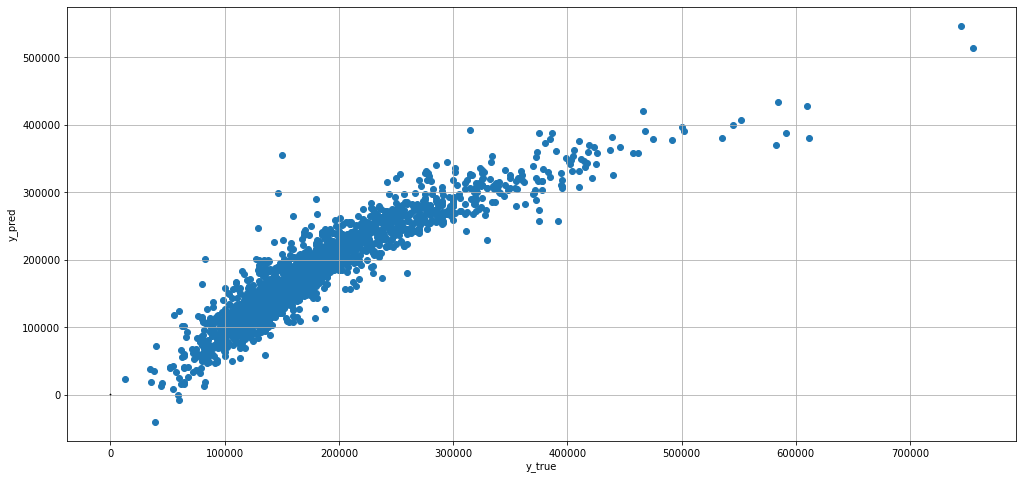

In [10]:
plt.figure(figsize=(17,8))
plt.scatter(x=train['SalePrice'], y=predictions)
plt.plot([0,50], [0,50], color='black')
plt.xlabel('y_true')
plt.ylabel('y_pred')
plt.grid()

## Get predictions for the test set

In [11]:
pd.isna(test[model_features]).sum()

MSSubClass       0
LotArea          0
OverallQual      0
OverallCond      0
YearBuilt        0
YearRemodAdd     0
1stFlrSF         0
2ndFlrSF         0
LowQualFinSF     0
GrLivArea        0
FullBath         0
HalfBath         0
BedroomAbvGr     0
KitchenAbvGr     0
TotRmsAbvGrd     0
Fireplaces       0
GarageCars       1
GarageArea       1
WoodDeckSF       0
OpenPorchSF      0
EnclosedPorch    0
3SsnPorch        0
ScreenPorch      0
PoolArea         0
MiscVal          0
MoSold           0
YrSold           0
dtype: int64

# Fill the missing values for prediction

In [12]:
test.fillna(test.mean(), inplace=True)

## Predict

In [13]:
test_predictions = model.predict(test[model_features])

submission = pd.read_csv('/kaggle/input/ml-for-softeng-assignment-2/sample_submission.csv')
submission['SalePrice'] = test_predictions

submission.head()

,Id,SalePrice
0,2054,248985.063994
1,2055,178603.153975
2,2056,214716.165031
3,2057,237827.513640
4,2058,411126.139938


### Save the results

In [14]:
submission.to_csv('submission.csv', index=False)